<a href="https://colab.research.google.com/github/gayathridevies-arch/Molecular-Descriptor-Analysis-and-3D-Structure-Simulation/blob/main/Molecular_Descriptor_Analysis_and_3D_Structure_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drug_like
True     1112
False      32
Name: count, dtype: int64


,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,mol,Molecular_Weight,LogP,NumHDonors,NumHAcceptors,TPSA,Num_rot_bonds,Fraction_sp3,Ring_count,Lipinski_Violations,Veber_Pass,Drug_like
0,"1,1,1,2-Tetrachloroethane",-2.180,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f89127efb50>,167.850,2.59540,0.0,0.0,0.00,0.0,1.000000,0.0,0,True,True
1,"1,1,1-Trichloroethane",-2.000,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f89127ef370>,133.405,2.37650,0.0,0.0,0.00,0.0,1.000000,0.0,0,True,True
2,"1,1,2,2-Tetrachloroethane",-1.740,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f89127eeb90>,167.850,2.59380,0.0,0.0,0.00,1.0,1.000000,0.0,0,True,True
3,"1,1,2-Trichloroethane",-1.480,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f89127efed0>,133.405,2.02890,0.0,0.0,0.00,1.0,1.000000,0.0,0,True,True
4,"1,1,2-Trichlorotrifluoroethane",-3.040,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f88e9c25460>,187.375,2.91890,0.0,0.0,0.00,1.0,1.000000,0.0,0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,vamidothion,1.144,-1.446,CNC(=O)C(C)SCCSP(=O)(OC)(OC),<rdkit.Chem.rdchem.Mol object at 0x7f88e9a9c890>,287.343,1.98820,1.0,6.0,64.63,8.0,0.875000,0.0,0,True,True
1140,Vinclozolin,-4.925,-4.377,CC1(OC(=O)N(C1=O)c2cc(Cl)cc(Cl)c2)C=C,<rdkit.Chem.rdchem.Mol object at 0x7f88e9a9fa00>,286.114,3.42130,0.0,3.0,46.61,2.0,0.166667,2.0,0,True,True
1141,Warfarin,-3.893,-3.913,CC(=O)CC(c1ccccc1)c3c(O)c2ccccc2oc3=O,<rdkit.Chem.rdchem.Mol object at 0x7f88e9a9fca0>,308.333,3.60960,1.0,4.0,67.51,4.0,0.157895,3.0,0,True,True
1142,Xipamide,-3.790,-3.642,Cc1cccc(C)c1NC(=O)c2cc(c(Cl)cc2O)S(N)(=O)=O,<rdkit.Chem.rdchem.Mol object at 0x7f88e9a9ce40>,354.815,2.56214,3.0,4.0,109.49,3.0,0.133333,2.0,0,True,True


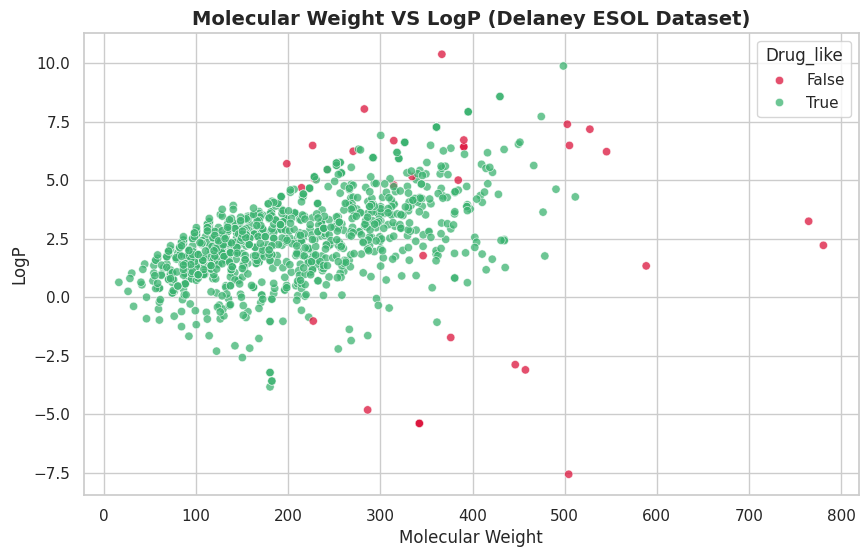

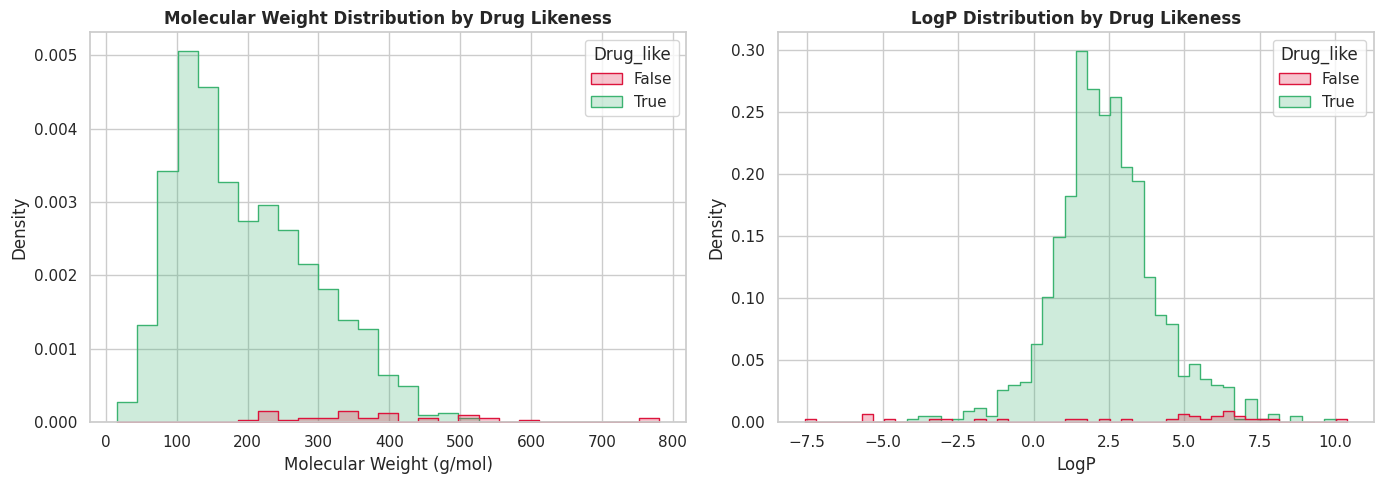

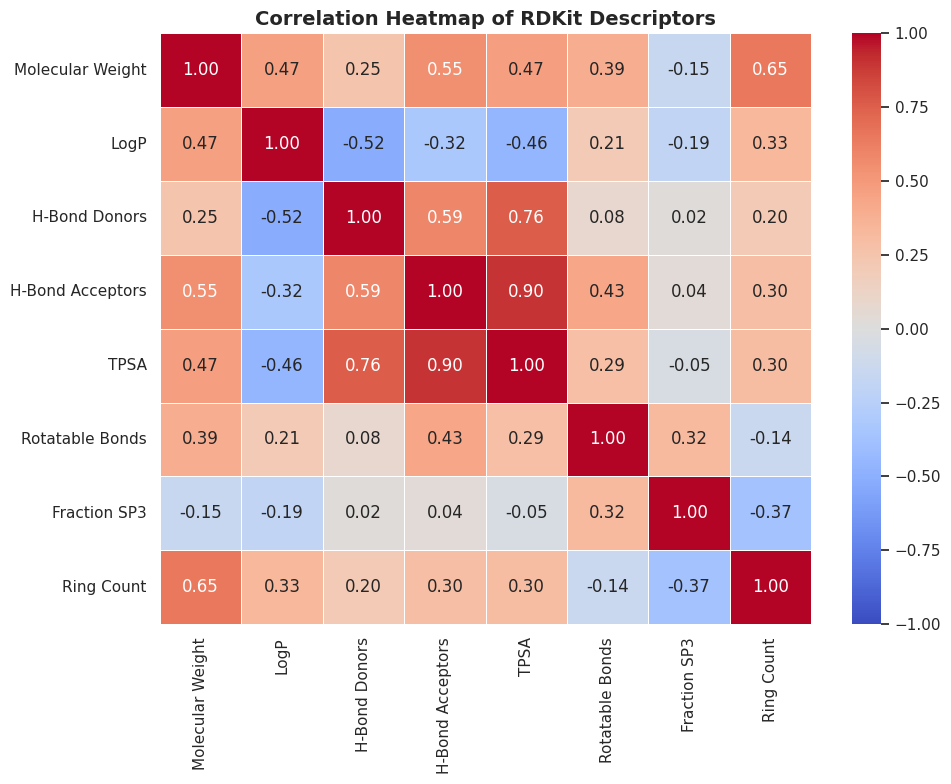

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [40]:
# ==========================================
# PART 1: SETUP & LIBRARIES
# ==========================================
!pip install rdkit
!pip install py3Dmol
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors,AllChem
import seaborn as sns
import matplotlib.pyplot as plt
import py3Dmol

# PART 2: DATA LOADING & 2D DESCRIPTORS
# ==========================================
# Load the Delaney solubility dataset

df=pd.read_csv("https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv")

# Function to calculate RDKit descriptors for each SMILES string

df["mol"]=df["SMILES"].apply(Chem.MolFromSmiles)
def calc_descriptors(calc):
  return pd.Series({"Molecular_Weight":Descriptors.MolWt(calc),"LogP":Descriptors.MolLogP(calc),"NumHDonors":Descriptors.NumHDonors(calc),"NumHAcceptors":Descriptors.NumHAcceptors(calc),"TPSA":Descriptors.TPSA(calc),"Num_rot_bonds":Descriptors.NumRotatableBonds(calc),"Fraction_sp3":Descriptors.FractionCSP3(calc),"Ring_count":Descriptors.RingCount(calc)})
descriptors_df=df["mol"].apply(calc_descriptors)

# Combine original data with our new descriptors

df=pd.concat([df,descriptors_df],axis=1)

# ==========================================
# PART 3: LIPINSKI & VEBER RULE FILTERING
# ==========================================

lipinski_v1=df["Molecular_Weight"]>500
lipinski_v2=df["LogP"]>5
lipinski_v3=df["NumHDonors"]>5
lipinski_v4=df["NumHAcceptors"]>10
df["Lipinski_Violations"]=lipinski_v1.astype(int)+lipinski_v2.astype(int)+lipinski_v3.astype(int)+lipinski_v4.astype(int)
df["Veber_Pass"]=(df["Num_rot_bonds"]<=10)&(df["TPSA"]<=140)
df["Drug_like"]=(df["Lipinski_Violations"]<=1) & (df["Veber_Pass"])
print(df["Drug_like"].value_counts())
display(df[df["Drug_like"]==True])

# ==========================================
# PART 4: SCATTER PLOT
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Molecular_Weight",y="LogP",hue="Drug_like",palette={True:"mediumseagreen",False:"crimson"},alpha=0.75)
plt.title("Molecular Weight VS LogP (Delaney ESOL Dataset)",fontsize=14,fontweight="bold")
plt.xlabel("Molecular Weight",fontsize=12)
plt.show()

# ==========================================
# PART 5: HISTOGRAM
# ==========================================

fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=df,x="Molecular_Weight",ax=axes[0],hue="Drug_like",palette={True:"mediumseagreen",False:"Crimson"},element="step",stat="density")
sns.histplot(data=df,x="LogP",ax=axes[1],hue="Drug_like",palette={True:"mediumseagreen",False:"Crimson"},element="step",stat="density")
axes[0].set_title("Molecular Weight Distribution by Drug Likeness",fontsize=12,fontweight="bold")
axes[1].set_title("LogP Distribution by Drug Likeness",fontsize=12,fontweight="bold")
axes[0].set_xlabel("Molecular Weight (g/mol)")
axes[0].set_ylabel("Density")
axes[1].set_ylabel("Density")
plt.tight_layout()
plt.show()


# ==========================================
# PART 5: HEATMAP
# ==========================================

numeric_cols=["Molecular_Weight","LogP","NumHDonors","NumHAcceptors","TPSA","Num_rot_bonds","Fraction_sp3","Ring_count"]
corr_matrix=df[numeric_cols].corr()
plt.figure(figsize=(10,8))
ax=sns.heatmap(corr_matrix,cmap="coolwarm",annot=True,fmt=".2f",vmin=-1,vmax=1,linewidths=0.5)
plt.title("Correlation Heatmap of RDKit Descriptors",fontweight="bold",fontsize=14)
Labels=["Molecular Weight","LogP","H-Bond Donors","H-Bond Acceptors","TPSA","Rotatable Bonds","Fraction SP3","Ring Count"]
ax.set_xticklabels(Labels)
ax.set_yticklabels(Labels)
plt.tight_layout()
plt.show()

# ==========================================
# PART 6: 3D MOLECULAR MODELING EXTENSION
# ==========================================

smiles_example="CC(=O)OC1=CC=CC=C1C(=O)O"
mol=Chem.MolFromSmiles(smiles_example)
mol=Chem.AddHs(mol)
AllChem.EmbedMolecule(mol)
AllChem.MMFFOptimizeMolecule(mol)
pdb_block=Chem.MolToPDBBlock(mol)
view=py3Dmol.view(width=400,height=300)
view.addModel(pdb_block,"pdb")
view.setStyle({"stick":{}})
view.zoomTo()
view.show()




